In [2]:
import ucimlrepo
import pandas as pd

from ucimlrepo import fetch_ucirepo

# fetch dataset
car_evaluation = fetch_ucirepo(id=19)

# data (as pandas dataframes)
X = car_evaluation.data.features
y = car_evaluation.data.targets

# metadata
print(car_evaluation.metadata)

# variable information
print(car_evaluation.variables)
df = pd.concat([X, y], axis=1)
df.head()

{'uci_id': 19, 'name': 'Car Evaluation', 'repository_url': 'https://archive.ics.uci.edu/dataset/19/car+evaluation', 'data_url': 'https://archive.ics.uci.edu/static/public/19/data.csv', 'abstract': 'Derived from simple hierarchical decision model, this database may be useful for testing constructive induction and structure discovery methods.', 'area': 'Other', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 1728, 'num_features': 6, 'feature_types': ['Categorical'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1988, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5JP48', 'creators': ['Marko Bohanec'], 'intro_paper': {'ID': 249, 'type': 'NATIVE', 'title': 'Knowledge acquisition and explanation for multi-attribute decision making', 'authors': 'M. Bohanec, V. Rajkovič', 'venue': '8th Intl Workshop on Expert Systems and their Applications, 

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [3]:
#1.data inspeciton
print(df.shape)
print(df.dtypes)
print(df.describe())
df.isnull().sum()
for column in df.columns:
    print(f"{column}:")
    print(df[column].value_counts())
    print()

(1728, 7)
buying      str
maint       str
doors       str
persons     str
lug_boot    str
safety      str
class       str
dtype: object
       buying  maint doors persons lug_boot safety  class
count    1728   1728  1728    1728     1728   1728   1728
unique      4      4     4       3        3      3      4
top     vhigh  vhigh     2       2    small    low  unacc
freq      432    432   432     576      576    576   1210
buying:
buying
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64

maint:
maint
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64

doors:
doors
2        432
3        432
4        432
5more    432
Name: count, dtype: int64

persons:
persons
2       576
4       576
more    576
Name: count, dtype: int64

lug_boot:
lug_boot
small    576
med      576
big      576
Name: count, dtype: int64

safety:
safety
low     576
med     576
high    576
Name: count, dtype: int64

class:
class
unacc    1210
acc       384
good       6

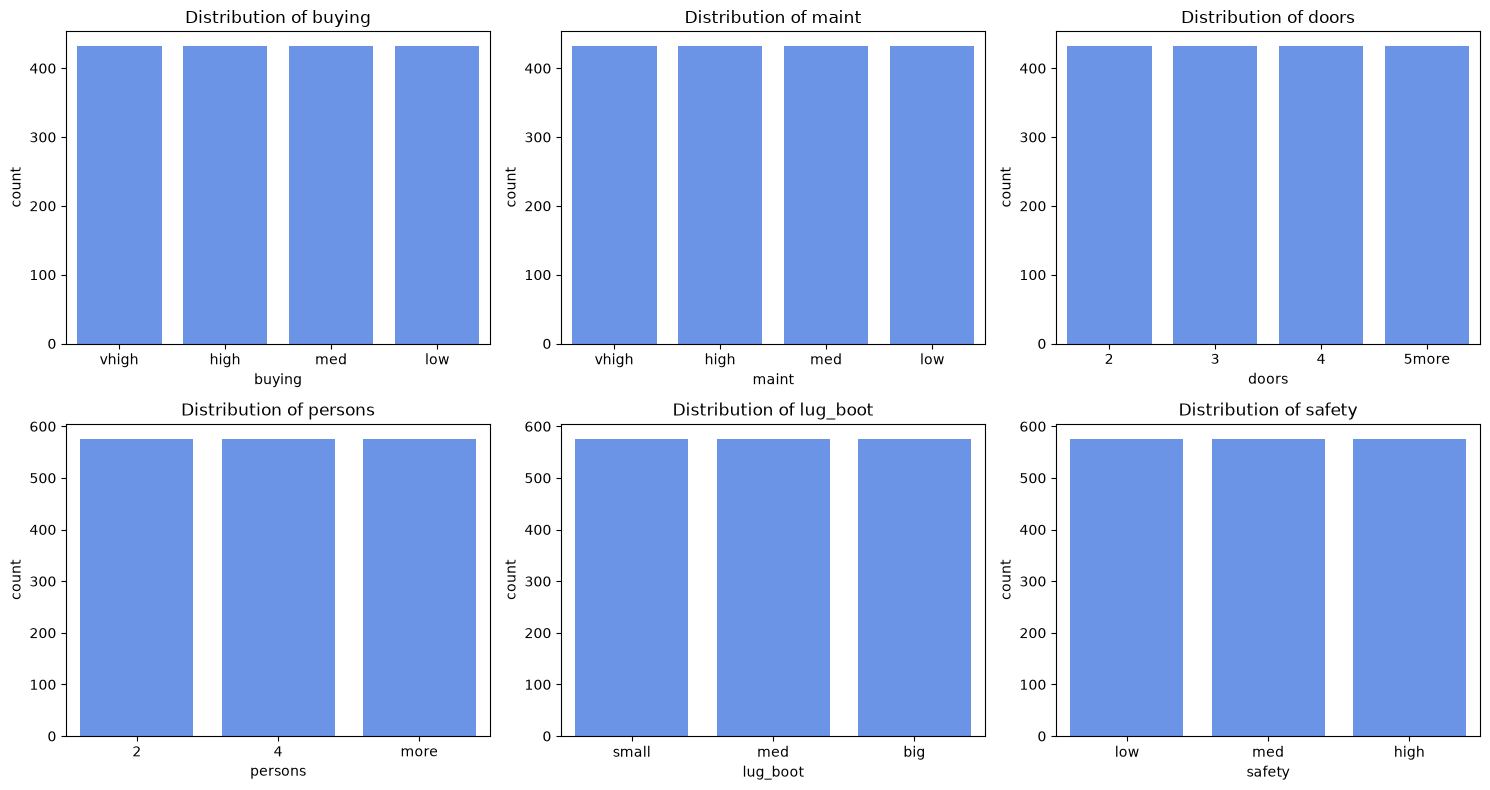

In [4]:
#2. Exploratory data analysis
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, column in enumerate(X.columns):
    ax = axes.flat[i]
    sns.countplot(data=X, x=column, ax=ax)
    ax.set_title(f'Distribution of {column}')

plt.tight_layout()
plt.show()

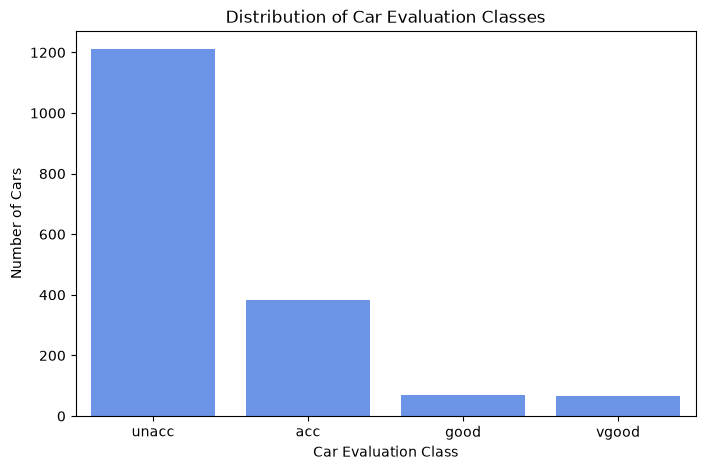

In [5]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='class',
    order=['unacc', 'acc', 'good', 'vgood']
)

plt.title('Distribution of Car Evaluation Classes')
plt.xlabel('Car Evaluation Class')
plt.ylabel('Number of Cars')
plt.show()

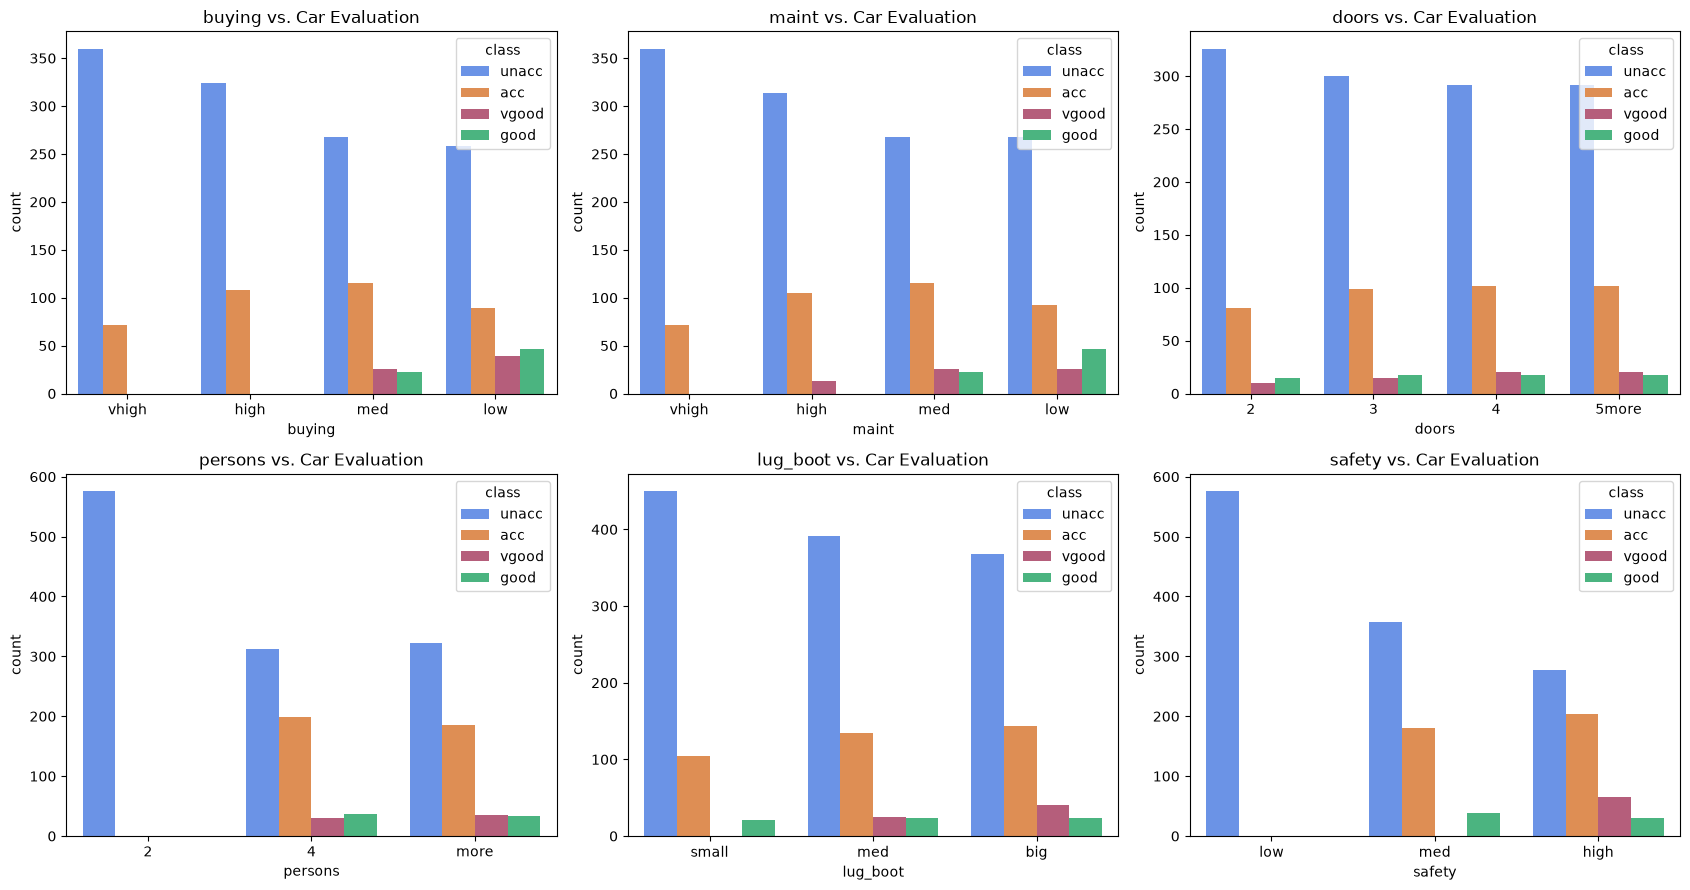

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))

for i, column in enumerate(X.columns):
    ax = axes.flat[i]

    sns.countplot(
        data=df,
        x=column,
        hue='class',
        ax=ax
    )

    ax.set_title(f'{column} vs. Car Evaluation')

plt.tight_layout()
plt.show()

In [8]:
#3.create binay target
y = (df['class'] != 'unacc').astype(int)

print(y.value_counts())

class
0    1210
1     518
Name: count, dtype: int64


In [10]:
#3.test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (1382, 6)
Testing: (346, 6)


In [11]:
# Step 4: Baseline Model - Decision Tree

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

baseline_model = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore')),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

baseline_model.fit(X_train, y_train)

print("Baseline model training completed!")

Baseline model training completed!


In [12]:
# Step 5: Baseline Model Evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

y_pred = baseline_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=['Unacceptable', 'Acceptable']
))

Accuracy: 0.9884393063583815
Precision: 0.9901960784313726
Recall: 0.9711538461538461
F1-score: 0.9805825242718447

Classification Report:
              precision    recall  f1-score   support

Unacceptable       0.99      1.00      0.99       242
  Acceptable       0.99      0.97      0.98       104

    accuracy                           0.99       346
   macro avg       0.99      0.98      0.99       346
weighted avg       0.99      0.99      0.99       346



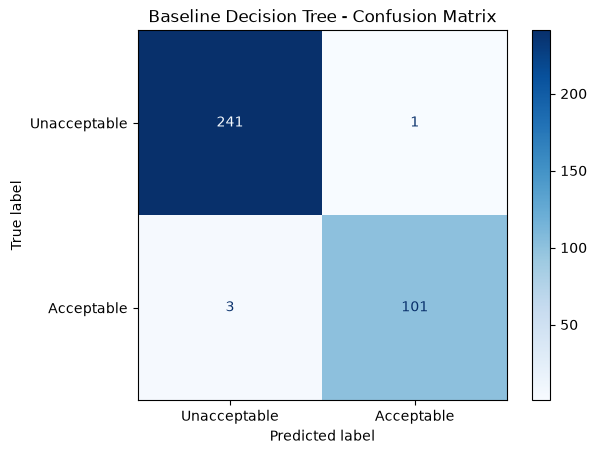

In [13]:
# Step 6: Confusion Matrix

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=[0, 1],
    display_labels=['Unacceptable', 'Acceptable'],
    cmap='Blues'
)

plt.title('Baseline Decision Tree - Confusion Matrix')
plt.show()

,Feature,Importance
12,persons_2,0.334019
19,safety_low,0.216875
0,buying_high,0.082723
3,buying_vhigh,0.062573
7,maint_vhigh,0.062202
4,maint_high,0.051618
20,safety_med,0.045307
17,lug_boot_small,0.045163
8,doors_2,0.031449
13,persons_4,0.020100


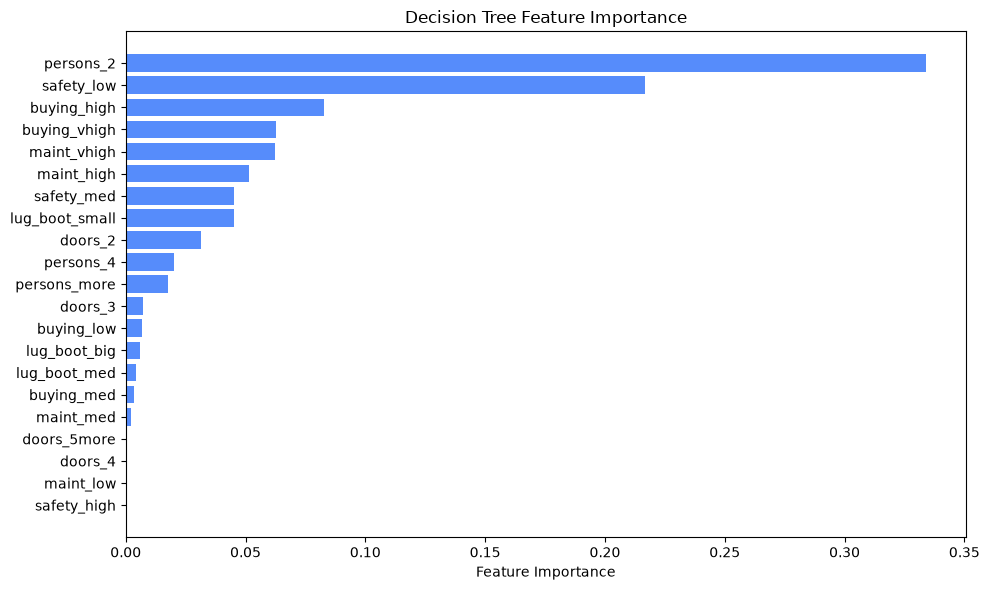

In [14]:
# Step 7: Feature Importance

import pandas as pd
import matplotlib.pyplot as plt

encoder = baseline_model.named_steps['encoder']
tree = baseline_model.named_steps['classifier']

importance_df = pd.DataFrame({
    'Feature': encoder.get_feature_names_out(),
    'Importance': tree.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

display(importance_df)

plt.figure(figsize=(10, 6))
plt.barh(
    importance_df['Feature'],
    importance_df['Importance']
)
plt.gca().invert_yaxis()
plt.xlabel('Feature Importance')
plt.title('Decision Tree Feature Importance')
plt.tight_layout()
plt.show()

In [15]:
# Step 8.1: Original Feature Importance

encoder = baseline_model.named_steps['encoder']
tree = baseline_model.named_steps['classifier']

importance = tree.feature_importances_

original_importance = {}

start = 0

for feature, categories in zip(
    X_train.columns,
    encoder.categories_
):
    end = start + len(categories)

    original_importance[feature] = importance[start:end].sum()

    start = end

importance_summary = pd.Series(
    original_importance
).sort_values(ascending=False)

print(importance_summary)

persons     0.371715
safety      0.262182
buying      0.155642
maint       0.116119
lug_boot    0.055564
doors       0.038779
dtype: float64


In [16]:
# Step 8.2: Feature Selection Experiment

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# All six original features
X_all = X_train

# Remove the least important original feature
X_selected = X_train.drop(columns=['doors'])

def evaluate_features(X_data):

    pipeline = Pipeline([
        ('encoder', OneHotEncoder(handle_unknown='ignore')),
        ('classifier', DecisionTreeClassifier(random_state=42))
    ])

    scores = cross_val_score(
        pipeline,
        X_data,
        y_train,
        cv=cv,
        scoring='f1'
    )

    return scores.mean()

all_score = evaluate_features(X_all)
selected_score = evaluate_features(X_selected)

print("All 6 features CV F1:", all_score)
print("Without doors CV F1:", selected_score)

All 6 features CV F1: 0.9670837394594841
Without doors CV F1: 0.9247918705435094


In [17]:
# Step 8.3: Compare Feature Removal

results = []

# Baseline: all features
results.append({
    'Removed Feature': 'None',
    'CV F1': evaluate_features(X_train)
})

# Remove one feature at a time
for feature in X_train.columns:

    X_reduced = X_train.drop(columns=[feature])

    score = evaluate_features(X_reduced)

    results.append({
        'Removed Feature': feature,
        'CV F1': score
    })

results_df = pd.DataFrame(results)

display(
    results_df.sort_values(
        by='CV F1',
        ascending=False
    )
)

,Removed Feature,CV F1
0,None,0.967084
3,doors,0.924792
5,lug_boot,0.822932
2,maint,0.762825
1,buying,0.747836
4,persons,0.330350
6,safety,0.295241


In [18]:
# Step 9: Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

tuning_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore')),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

param_grid = {
    'classifier__max_depth': [5, 10, 15, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=tuning_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV F1:", grid_search.best_score_)

Best Parameters: {'classifier__max_depth': 15, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}
Best CV F1: 0.9670837394594841


In [19]:
# Step 10: Alternative Model - Random Forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import cross_val_score

rf_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore')),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

rf_scores = cross_val_score(
    rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring='f1'
)

print("Random Forest CV F1 Scores:", rf_scores)
print("Random Forest Mean CV F1:", rf_scores.mean())
print("Random Forest CV Std:", rf_scores.std())

Random Forest CV F1 Scores: [0.98224852 0.9704142  0.92857143 0.97005988 0.96428571]
Random Forest Mean CV F1: 0.9631159489980309
Random Forest CV Std: 0.018233102910346168


Final Test Accuracy: 0.9884393063583815
Final Test Precision: 0.9901960784313726
Final Test Recall: 0.9711538461538461
Final Test F1: 0.9805825242718447

Final Classification Report:
              precision    recall  f1-score   support

Unacceptable       0.99      1.00      0.99       242
  Acceptable       0.99      0.97      0.98       104

    accuracy                           0.99       346
   macro avg       0.99      0.98      0.99       346
weighted avg       0.99      0.99      0.99       346



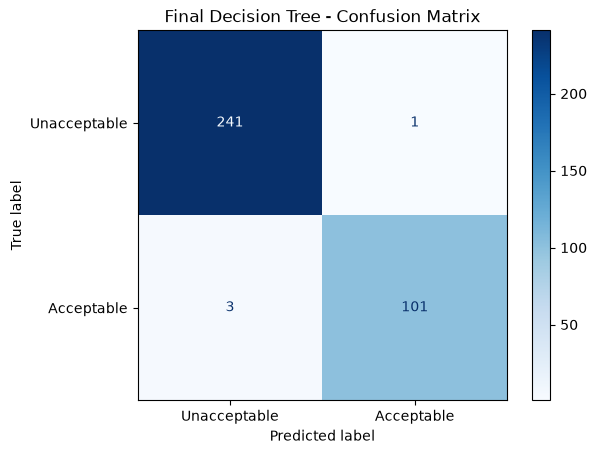

In [20]:
# Step 11: Final Model Evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

final_model = grid_search.best_estimator_

y_final_pred = final_model.predict(X_test)

print("Final Test Accuracy:",
      accuracy_score(y_test, y_final_pred))

print("Final Test Precision:",
      precision_score(y_test, y_final_pred))

print("Final Test Recall:",
      recall_score(y_test, y_final_pred))

print("Final Test F1:",
      f1_score(y_test, y_final_pred))

print("\nFinal Classification Report:")
print(classification_report(
    y_test,
    y_final_pred,
    target_names=['Unacceptable', 'Acceptable']
))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_final_pred,
    labels=[0, 1],
    display_labels=['Unacceptable', 'Acceptable'],
    cmap='Blues'
)

plt.title("Final Decision Tree - Confusion Matrix")
plt.show()